# Phase 2 — Calcul des Indicateurs de Surveillance
## Système de Surveillance Intelligent — Bourse de Casablanca

**Objectif :** Calculer l'ensemble des indicateurs nécessaires à la détection d'anomalies :

| Niveau | Indicateurs |
|---|---|
| Marché Global | MASI vol., breadth, volume relatif, HHI concentration |
| Instrument | Rendement, volatilité 5/10/20j, RSI, momentum, spread, turnover |
| Flux d'Ordres | OIR (Lee-Ready), OAR, VWAP, volatilité intraday |
| Scoring | Score d'alerte [0-100] avec sévérité (Normal / Faible / Modéré / Critique) |

---
## 0. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_from_cache
from src.indicators import (
    compute_market_indicators,
    compute_instrument_indicators,
    compute_orderflow_indicators,
    compute_alert_scores,
    seuils_statistiques,
    get_top_alerts,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid', palette='muted')

print('✓ Imports OK')

✓ Imports OK


---
## 1. Chargement des données (depuis cache Parquet)

In [2]:
data = load_from_cache()
if data is None:
    from src.data_loader import load_excel, save_to_cache
    data = load_excel()
    save_to_cache(data)

df_ind   = data['indicateurs'].copy()
df_idx   = data['indices'].copy()
df_cours = data['cours'].copy()
df_intra = data['intraday'].copy()

for name, df in data.items():
    print(f'[{name}] : {len(df):,} lignes | {len(df.columns)} colonnes')

[indicateurs] : 247 lignes | 9 colonnes
[indices] : 494 lignes | 7 colonnes
[cours] : 19,164 lignes | 22 colonnes
[intraday] : 403,466 lignes | 14 colonnes


---
## 2. Indicateurs Marché Global

In [3]:
# Préparation : calcul rendements instruments pour breadth
df_cours_temp = df_cours.copy()
df_cours_temp = df_cours_temp.sort_values(['Ticker','Jour'])
df_cours_temp['Rendement_pct'] = df_cours_temp.groupby('Ticker')['Cours_Cloture'].pct_change() * 100

df_market = compute_market_indicators(df_ind, df_idx, df_cours_temp)
print(f'Indicateurs marché : {len(df_market)} séances | {len(df_market.columns)} colonnes')
display(df_market.tail(10))

Indicateurs marché : 247 séances | 21 colonnes


,Jour,Volume_MAD,Quantite_Titres,Nb_Contrats,MASI,MASI_Var_Veille_pct,MASI_Var_YTD_pct,MSI20,MSI20_Var_Veille_pct,MASI_Return_pct,MASI_Vol_5j,MASI_Vol_20j,Vol_Moyen_20j,Volume_Relatif_Marche,Volume_Par_Contrat,Breadth_pct,HHI_Volume,Z_Volume_MAD,Z_MASI_Return_pct,Z_MASI_Vol_20j,Z_Volume_Relatif_Marche
237,2025-12-18,"328,984,963.0300",868555,8200,"18,869.5974",0.3000,27.3700,"1,527.3045",0.0800,0.5434,0.2695,0.4046,"306,417,871.2710",1.0736,"40,120.1174",45.4545,0.0786,-0.4927,0.5163,-1.3212,0.0693
238,2025-12-19,"1,167,077,904.9800",3750789,7891,"19,005.8247",0.6500,28.1900,"1,531.8182",0.5400,0.7219,0.3192,0.4153,"345,355,821.8760",3.3793,"147,899.8739",38.9610,0.1217,2.0877,0.7213,-1.2868,3.8972
239,2025-12-22,"229,764,699.7500",552914,6396,"18,983.6384",0.0200,28.2200,"1,530.6790",-0.4300,-0.1167,0.3977,0.4068,"347,183,884.5640",0.6618,"35,923.1863",36.3636,0.1149,-0.7982,-0.2416,-1.3142,-0.6145
240,2025-12-23,"796,646,441.5300",1459907,6758,"18,966.1581",0.0100,28.2300,"1,522.2732",-0.4500,-0.0921,0.3902,0.3951,"376,757,609.9015",2.1145,"117,881.9831",37.6623,0.2206,0.9472,-0.2133,-1.3520,1.7973
241,2025-12-24,"763,264,797.9200",1606267,10320,"19,001.9701",-0.1400,28.0500,"1,516.7298",-0.9100,0.1888,0.3755,0.3890,"397,648,409.4685",1.9194,"73,959.7672",29.8701,0.3078,0.8444,0.1092,-1.3716,1.4735
242,2025-12-25,"1,132,961,340.1200",2770314,12766,"19,048.8699",0.1300,28.2100,"1,511.2373",-0.2100,0.2468,0.3391,0.3745,"437,376,166.8330",2.5904,"88,748.3425",45.4545,0.2707,1.9827,0.1758,-1.4186,2.5873
243,2025-12-26,"3,352,763,404.7500",5451141,27089,"19,144.1444",-2.4500,25.0700,"1,506.8798",-2.4300,0.5002,0.2565,0.3845,"589,878,039.0540",5.6838,"123,768.4449",33.7662,0.3535,8.8172,0.4667,-1.3862,7.7231
244,2025-12-29,"1,322,433,574.3300",2548101,25474,"18,813.2271",-0.4900,24.4600,"1,492.7685",-0.5400,-1.7286,0.8925,0.5600,"649,735,598.0895",2.0353,"51,913.0711",29.8701,0.3211,2.5660,-2.0922,-0.8192,1.6659
245,2025-12-30,"1,788,938,270.9400",4315338,15030,"18,672.9038",1.4600,26.2700,"1,476.8641",1.5900,-0.7459,0.9243,0.5477,"732,929,990.6720",2.4408,"119,024.5024",45.4545,0.1405,4.0024,-0.9640,-0.8588,2.3390
246,2025-12-31,"1,184,484,751.6100",2945622,14471,"18,869.7988",1.0300,27.5700,"1,487.6924",0.7300,1.0544,1.1041,0.5883,"778,523,025.3400",1.5215,"81,852.3082",49.3506,0.1625,2.1413,1.1030,-0.7277,0.8127


In [4]:
# Seuils statistiques des indicateurs marché
seuils_market = pd.DataFrame([
    seuils_statistiques(df_market['MASI_Return_pct'], 'MASI Rendement (%)'),
    seuils_statistiques(df_market['MASI_Vol_20j'], 'MASI Volatilité 20j (%)'),
    seuils_statistiques(df_market['Volume_Relatif_Marche'], 'Volume Relatif Marché'),
    seuils_statistiques(df_market.get('Breadth_pct', pd.Series(dtype=float)), 'Breadth (% hausse)'),
    seuils_statistiques(df_market.get('HHI_Volume', pd.Series(dtype=float)), 'HHI Concentration'),
])
print('=== SEUILS STATISTIQUES — MARCHÉ GLOBAL ===')
display(seuils_market[['indicateur','moyenne','ecart_type','P01','P95','P99',
                         'Seuil_Alerte_Haut','Seuil_Critique_Haut']])

=== SEUILS STATISTIQUES — MARCHÉ GLOBAL ===


,indicateur,moyenne,ecart_type,P01,P95,P99,Seuil_Alerte_Haut,Seuil_Critique_Haut
0,MASI Rendement (%),0.0937,0.8710,-2.2342,1.6179,2.5016,1.8357,2.7066
1,MASI Volatilité 20j (%),0.8136,0.3095,0.3912,1.5036,1.6728,1.4326,1.7421
2,Volume Relatif Marché,1.0319,0.6023,0.2559,1.9555,2.7993,2.2366,2.8389
3,Breadth (% hausse),38.4400,13.3887,8.6133,59.7918,69.2259,65.2175,78.6062
4,HHI Concentration,0.1046,0.0690,0.0501,0.2299,0.4027,0.2427,0.3117


In [5]:
# Dashboard marché global
fig = make_subplots(
    rows=4, cols=1, shared_xaxes=True,
    subplot_titles=[
        'MASI — Niveau & Volatilité Rolling 20j',
        'Volume Relatif Marché (ratio vs moy. 20j)',
        'Breadth du Marché (% titres en hausse)',
        'Concentration HHI des Volumes'
    ],
    vertical_spacing=0.07
)

# MASI
fig.add_trace(go.Scatter(x=df_market['Jour'], y=df_market['MASI'],
    name='MASI', line=dict(color='royalblue', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=df_market['Jour'], y=df_market['MASI_Vol_20j'],
    name='Volatilité 20j', yaxis='y2', line=dict(color='crimson', width=1.5, dash='dot'),
    opacity=0.8), row=1, col=1)

# Volume relatif
colors_vr = ['crimson' if v > 2 else 'darkorange' if v > 1.5 else 'steelblue'
             for v in df_market['Volume_Relatif_Marche'].fillna(0)]
fig.add_trace(go.Bar(x=df_market['Jour'], y=df_market['Volume_Relatif_Marche'],
    name='Vol. Relatif', marker_color=colors_vr), row=2, col=1)
fig.add_hline(y=2.0, line_dash='dash', line_color='crimson', row=2, col=1)
fig.add_hline(y=1.5, line_dash='dot', line_color='orange', row=2, col=1)

# Breadth
if 'Breadth_pct' in df_market.columns:
    fig.add_trace(go.Scatter(x=df_market['Jour'], y=df_market['Breadth_pct'],
        name='Breadth (%)', fill='tozeroy',
        line=dict(color='mediumseagreen', width=1.5)), row=3, col=1)
    fig.add_hline(y=50, line_dash='dash', line_color='gray', row=3, col=1)

# HHI
if 'HHI_Volume' in df_market.columns:
    fig.add_trace(go.Scatter(x=df_market['Jour'], y=df_market['HHI_Volume'],
        name='HHI Concentration', line=dict(color='mediumpurple', width=1.5)), row=4, col=1)

fig.update_layout(height=800, title_text='Tableau de Bord — Indicateurs Marché Global BVC 2025',
                   showlegend=False)
fig.show()

---
## 3. Indicateurs par Instrument

In [6]:
df_instr = compute_instrument_indicators(df_cours)
print(f'Indicateurs instruments : {len(df_instr):,} lignes | {len(df_instr.columns)} colonnes')
print(f'Nouveaux indicateurs calculés :')
new_cols = [c for c in df_instr.columns if c not in df_cours.columns]
print(' |'.join(new_cols))

Indicateurs instruments : 19,164 lignes | 34 colonnes
Nouveaux indicateurs calculés :
Ecart_Ref_Cloture_pct |Volatilite_5j |Volatilite_10j |Volatilite_20j |RSI_14j |Momentum_5j |Momentum_20j |Z_Volume |Z_Volatilite |Pct_Volume_Rank |Pct_Volatilite_Rank |Score_Liquidite


In [7]:
# Seuils statistiques des indicateurs instruments
seuils_instr = pd.DataFrame([
    seuils_statistiques(df_instr['Rendement_pct'].dropna(), 'Rendement (%)'),
    seuils_statistiques(df_instr['Volatilite_5j'].dropna(), 'Volatilité 5j (%)'),
    seuils_statistiques(df_instr['Volatilite_20j'].dropna(), 'Volatilité 20j (%)'),
    seuils_statistiques(df_instr['Volume_Relatif'].dropna(), 'Volume Relatif'),
    seuils_statistiques(df_instr['Turnover_Ratio'].dropna(), 'Turnover Ratio'),
    seuils_statistiques(df_instr['Spread_pct'].dropna(), 'Spread Bid-Ask (%)'),
    seuils_statistiques(df_instr['Range_pct'].dropna(), 'Range Journalier (%)'),
    seuils_statistiques(df_instr['RSI_14j'].dropna(), 'RSI 14j'),
])
print('=== SEUILS STATISTIQUES — INSTRUMENTS ===')
display(seuils_instr[['indicateur','N','moyenne','ecart_type','P01','P95','P99',
                        'Seuil_Alerte_Haut','Seuil_Critique_Haut']])

=== SEUILS STATISTIQUES — INSTRUMENTS ===


,indicateur,N,moyenne,ecart_type,P01,P95,P99,Seuil_Alerte_Haut,Seuil_Critique_Haut
0,Rendement (%),18319,0.1467,2.5134,-6.4429,4.7094,9.9140,5.1735,7.6869
1,Volatilité 5j (%),18165,1.9819,1.4855,0.0000,4.8798,6.9709,4.9530,6.4385
2,Volatilité 20j (%),17626,2.2222,1.1306,0.0981,4.3120,5.7497,4.4833,5.6139
3,Volume Relatif,15793,1.0366,1.5489,0.0036,3.8804,7.8556,4.1345,5.6834
4,Turnover Ratio,16172,0.0011,0.0031,0.0000,0.0044,0.0139,0.0073,0.0104
5,Spread Bid-Ask (%),17787,3.9875,4.1243,0.2105,10.9978,23.7006,12.2361,16.3604
6,Range Journalier (%),16172,2.5313,2.2902,0.0000,6.9418,10.2080,7.1117,9.4018
7,RSI 14j,17519,49.6780,6.6258,31.5749,59.0432,66.0554,62.9296,69.5554


Instrument exemple : GTM — SGTM S.A


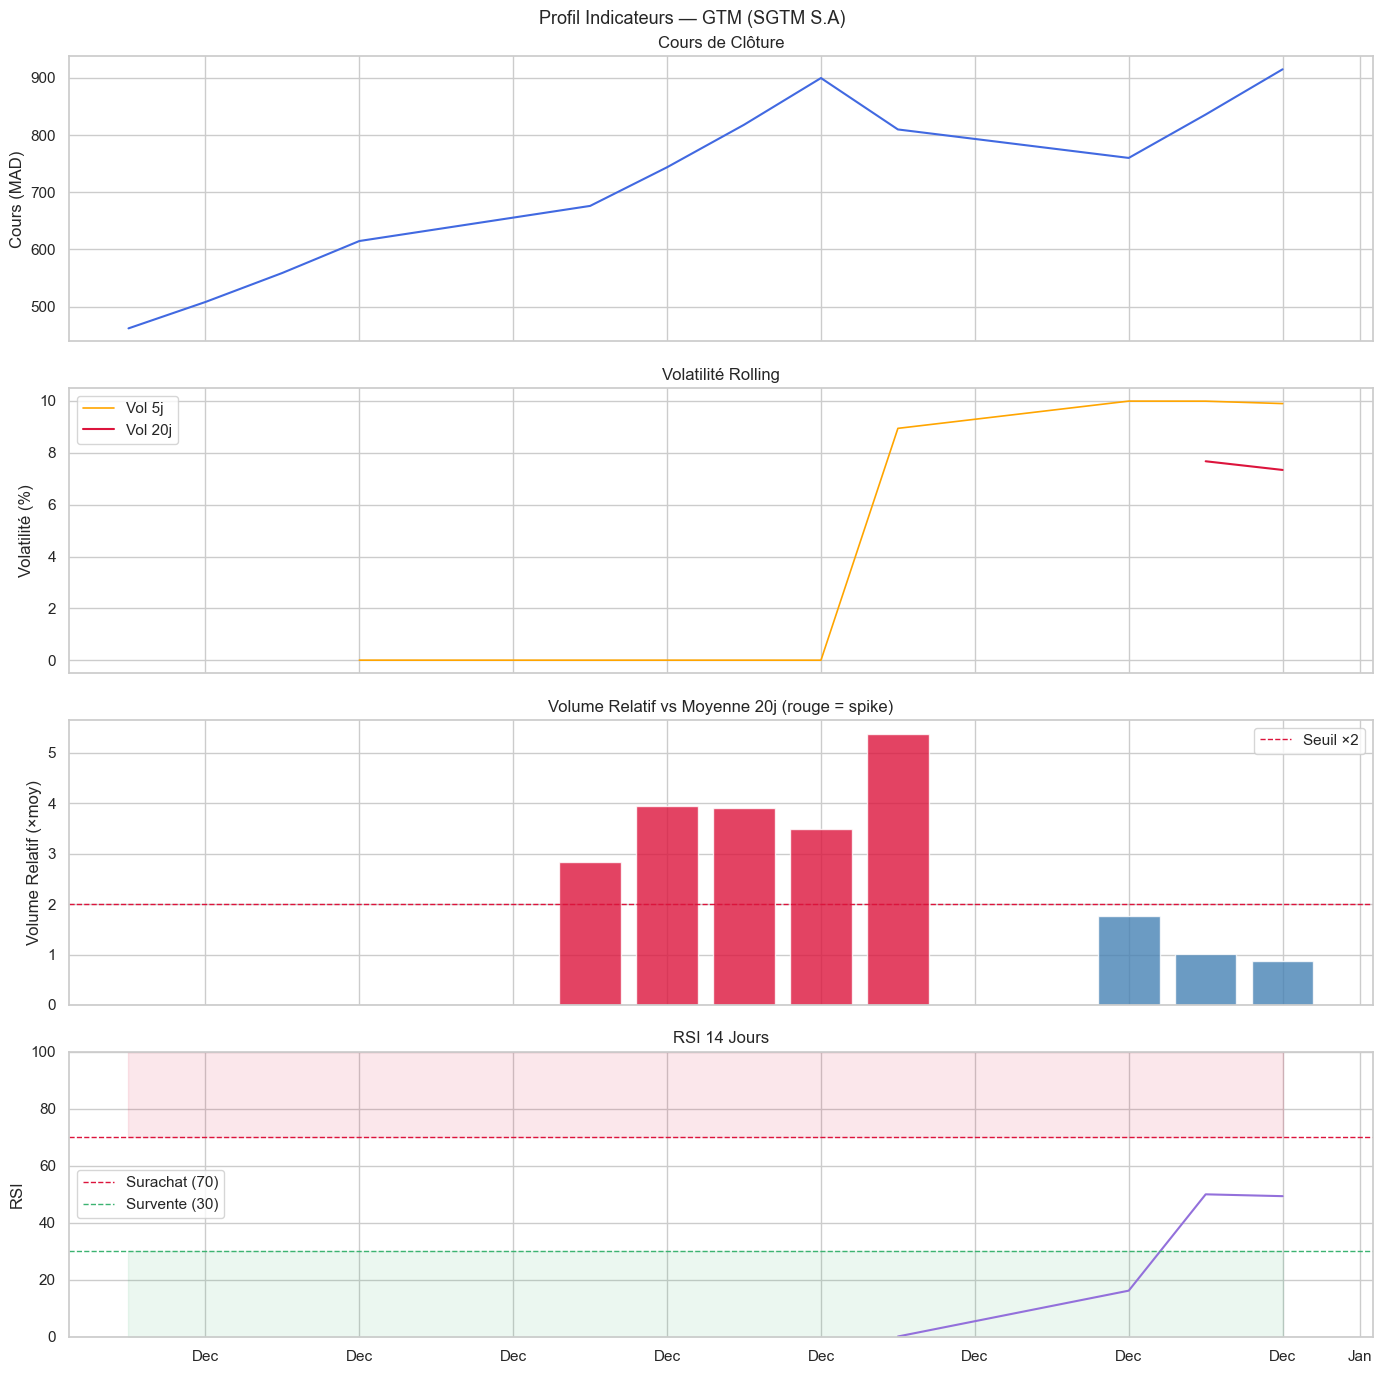

In [8]:
# Profil d'un instrument exemple : le plus volumineux
top_ticker = df_instr.groupby('Ticker')['Volume_MAD'].mean().idxmax()
df_ex = df_instr[df_instr['Ticker'] == top_ticker].copy()
print(f'Instrument exemple : {top_ticker} — {df_ex["Libelle"].iloc[0]}')

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle(f'Profil Indicateurs — {top_ticker} ({df_ex["Libelle"].iloc[0]})', fontsize=13)

# Cours
axes[0].plot(df_ex['Jour'], df_ex['Cours_Cloture'], color='royalblue', linewidth=1.5)
axes[0].set_ylabel('Cours (MAD)')
axes[0].set_title('Cours de Clôture')

# Volatilités rolling
axes[1].plot(df_ex['Jour'], df_ex['Volatilite_5j'], label='Vol 5j', color='orange', linewidth=1.2)
axes[1].plot(df_ex['Jour'], df_ex['Volatilite_20j'], label='Vol 20j', color='crimson', linewidth=1.5)
axes[1].set_ylabel('Volatilité (%)')
axes[1].set_title('Volatilité Rolling')
axes[1].legend()

# Volume relatif
colors_vol = ['crimson' if v > 2 else 'steelblue' for v in df_ex['Volume_Relatif'].fillna(1)]
axes[2].bar(df_ex['Jour'], df_ex['Volume_Relatif'], color=colors_vol, alpha=0.8, width=0.8)
axes[2].axhline(2.0, color='crimson', linestyle='--', linewidth=1, label='Seuil ×2')
axes[2].set_ylabel('Volume Relatif (×moy)')
axes[2].set_title('Volume Relatif vs Moyenne 20j (rouge = spike)')
axes[2].legend()

# RSI
axes[3].plot(df_ex['Jour'], df_ex['RSI_14j'], color='mediumpurple', linewidth=1.5)
axes[3].axhline(70, color='crimson', linestyle='--', linewidth=1, label='Surachat (70)')
axes[3].axhline(30, color='mediumseagreen', linestyle='--', linewidth=1, label='Survente (30)')
axes[3].fill_between(df_ex['Jour'], 70, 100, alpha=0.1, color='crimson')
axes[3].fill_between(df_ex['Jour'], 0, 30, alpha=0.1, color='mediumseagreen')
axes[3].set_ylabel('RSI')
axes[3].set_ylim(0, 100)
axes[3].set_title('RSI 14 Jours')
axes[3].legend()
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig(f'../reports/06_profil_instrument_{top_ticker}.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Scatter : Volatilité vs Volume Relatif (par instrument, agrégé sur l'année)
resume = df_instr.groupby('Ticker').agg(
    Volatilite_Moy=('Volatilite_20j', 'mean'),
    Volume_Relatif_Moy=('Volume_Relatif', 'mean'),
    Turnover_Moy=('Turnover_Ratio', 'mean'),
    RSI_Moy=('RSI_14j', 'mean'),
    Libelle=('Libelle', 'first'),
).reset_index().dropna()

fig = px.scatter(
    resume,
    x='Volume_Relatif_Moy', y='Volatilite_Moy',
    size='Turnover_Moy', color='RSI_Moy',
    color_continuous_scale='RdYlGn',
    text='Ticker',
    hover_data=['Libelle', 'Turnover_Moy'],
    title='Cartographie Volatilité vs Volume — Instruments BVC 2025',
    labels={
        'Volume_Relatif_Moy': 'Volume Relatif Moyen (×moy 20j)',
        'Volatilite_Moy': 'Volatilité Moyenne 20j (%)',
        'RSI_Moy': 'RSI Moyen'
    }
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=600)
fig.show()

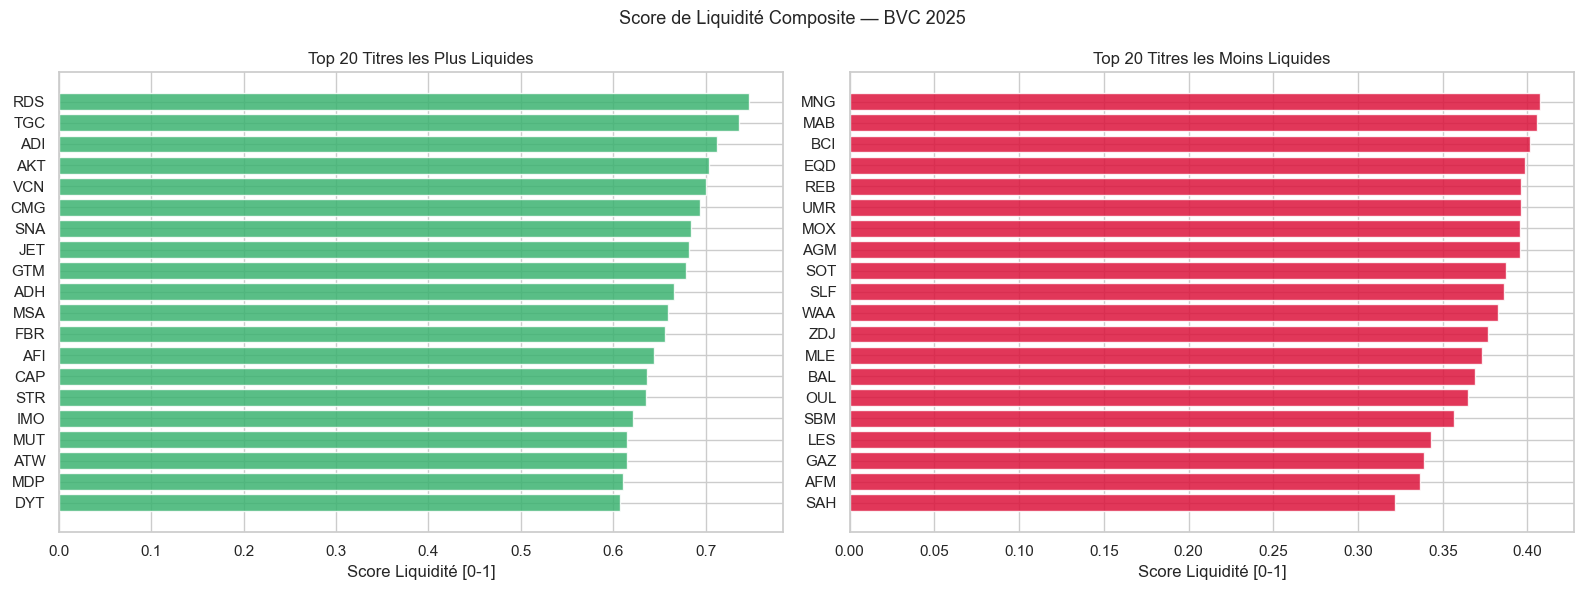

In [10]:
# Score de liquidité : classement des instruments
liq_rank = (df_instr.groupby('Ticker')
            .agg(Score_Liq=('Score_Liquidite','mean'),
                 Spread_Moy=('Spread_pct','mean'),
                 Turnover_Moy=('Turnover_Ratio','mean'),
                 Libelle=('Libelle','first'))
            .sort_values('Score_Liq', ascending=False)
            .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(liq_rank.head(20)['Ticker'][::-1],
             liq_rank.head(20)['Score_Liq'][::-1], color='mediumseagreen', alpha=0.85)
axes[0].set_xlabel('Score Liquidité [0-1]')
axes[0].set_title('Top 20 Titres les Plus Liquides')
axes[1].barh(liq_rank.tail(20)['Ticker'][::-1],
             liq_rank.tail(20)['Score_Liq'][::-1], color='crimson', alpha=0.85)
axes[1].set_xlabel('Score Liquidité [0-1]')
axes[1].set_title('Top 20 Titres les Moins Liquides')
plt.suptitle('Score de Liquidité Composite — BVC 2025', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/07_scores_liquidite.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Indicateurs de Flux d'Ordres (OIR Lee-Ready, VWAP, OAR)

In [11]:
print('Calcul des indicateurs intraday (Lee-Ready OIR)...')
df_of = compute_orderflow_indicators(df_intra, df_cours)
print(f'Order Flow DataFrame : {len(df_of):,} lignes | {len(df_of.columns)} colonnes')
print(f'Période : {df_of["Jour"].min().date()} → {df_of["Jour"].max().date()}')
print(f'Instruments : {df_of["Ticker"].nunique()}')
display(df_of.describe())

Calcul des indicateurs intraday (Lee-Ready OIR)...


Order Flow DataFrame : 1,549 lignes | 23 colonnes
Période : 2025-12-01 → 2025-12-31
Instruments : 77


,Jour,Nb_Transactions,Volume_Intraday,Buy_Volume,Sell_Volume,Cours_Min,Cours_Max,Cours_Std,VWAP,Duree_Active_min,OIR,OAR,Volatilite_Intraday,Pct_Vol_Open,Pct_Vol_Close,Cours_Cloture,Cours_Ref,VWAP_Dev_pct,Z_OIR,Z_OAR,Z_Volatilite_Intraday,Z_Nb_Transactions
count,1549,"1,549.0000","1,549.0000","1,549.0000","1,549.0000","1,549.0000","1,549.0000","1,467.0000","1,549.0000","1,549.0000","1,549.0000","1,342.0000","1,467.0000","1,163.0000","1,139.0000","1,549.0000","1,549.0000","1,549.0000","1,549.0000","1,342.0000","1,467.0000","1,549.0000"
mean,2025-12-15 21:14:31.530019072,130.2343,"24,385.6127","10,926.3841","13,459.2285","1,004.0385","1,027.0657",8.9173,"1,015.3230",274.4771,0.2455,118.4958,0.8882,17.7048,44.6084,"1,016.1957","1,015.0737",-0.1044,-0.0000,-0.0000,-0.0000,0.0000
min,2025-12-01 00:00:00,1.0000,1.0000,1.0000,0.0000,26.2000,26.9800,0.0000,26.6012,0.0000,-0.9994,0.3343,0.0000,0.0015,0.0029,26.3300,26.3300,-7.9612,-1.8306,-0.0745,-1.0653,-0.1582
25%,2025-12-08 00:00:00,8.0000,92.0000,42.0000,5.0000,221.0000,229.8500,0.7038,224.5714,229.0000,-0.3333,3.1757,0.3505,1.5661,13.0701,225.0000,225.0000,-0.5449,-0.8511,-0.0728,-0.6449,-0.1497
50%,2025-12-16 00:00:00,27.0000,"1,134.0000",451.0000,245.0000,470.0000,475.5000,2.5616,471.6542,358.0000,0.3544,6.5653,0.7344,6.2372,40.5671,472.9000,472.9500,0.0000,0.1600,-0.0706,-0.1845,-0.1264
75%,2025-12-24 00:00:00,72.0000,"7,470.0000","2,923.0000","2,664.0000","1,277.0000","1,297.0000",8.3130,"1,285.0000",362.0000,0.9565,14.8658,1.1911,22.8086,73.9081,"1,288.0000","1,290.0000",0.4335,1.0454,-0.0654,0.3633,-0.0713
max,2025-12-31 00:00:00,"19,031.0000","2,213,394.0000","1,759,992.0000","2,145,679.0000","6,677.0000","6,677.0000",253.9732,"6,677.0000",372.0000,1.0000,"39,933.3333",9.1468,100.0000,100.0000,"6,677.0000","6,677.0000",13.3502,1.1093,25.1195,9.9050,23.1436
std,NaN,816.6748,"118,117.8782","62,182.9084","89,287.9370","1,287.0008","1,314.5333",18.5693,"1,301.3695",134.9411,0.6801,"1,585.0183",0.8338,25.1419,33.3751,"1,302.2417","1,300.4907",1.2105,1.0000,1.0000,1.0000,1.0000


In [12]:
# Seuils OIR, OAR, Volatilité intraday
seuils_of = pd.DataFrame([
    seuils_statistiques(df_of['OIR'].dropna(), 'OIR (Order Imbalance Ratio)'),
    seuils_statistiques(df_of['OAR'].dropna(), 'OAR (Order Arrival Rate)'),
    seuils_statistiques(df_of['Volatilite_Intraday'].dropna(), 'Volatilité Intraday (%)'),
    seuils_statistiques(df_of['Nb_Transactions'].dropna(), 'Nb Transactions'),
    seuils_statistiques(df_of['VWAP_Dev_pct'].dropna(), 'VWAP Déviation (%)'),
])
print('=== SEUILS STATISTIQUES — FLUX D\'ORDRES ===')
display(seuils_of[['indicateur','N','moyenne','ecart_type','P01','P95','P99',
                    'Seuil_Alerte_Haut','Seuil_Critique_Haut']])

=== SEUILS STATISTIQUES — FLUX D'ORDRES ===


,indicateur,N,moyenne,ecart_type,P01,P95,P99,Seuil_Alerte_Haut,Seuil_Critique_Haut
0,OIR (Order Imbalance Ratio),1549,0.2455,0.6801,-0.9880,1.0000,1.0000,1.6058,2.2859
1,OAR (Order Arrival Rate),1342,118.4958,"1,585.0183",0.6969,57.1473,738.3931,"3,288.5324","4,873.5508"
2,Volatilité Intraday (%),1467,0.8882,0.8338,0.0000,2.3029,3.8117,2.5558,3.3896
3,Nb Transactions,1549,130.2343,816.6748,1.0000,294.4000,"1,340.7200","1,763.5840","2,580.2588"
4,VWAP Déviation (%),1549,-0.1044,1.2105,-3.9497,1.4355,2.5970,2.3166,3.5271


In [13]:
# Visualisation OIR par instrument (agrégé sur décembre)
oir_mean = (df_of.groupby('Ticker')['OIR'].mean()
            .sort_values().reset_index())

fig = px.bar(
    oir_mean,
    x='Ticker', y='OIR',
    title='OIR Moyen par Instrument — Décembre 2025 (Lee-Ready)',
    color='OIR',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    labels={'OIR': 'Order Imbalance Ratio (-1=vente, +1=achat)'}
)
fig.add_hline(y=0.3, line_dash='dash', line_color='crimson', annotation_text='Seuil Alerte')
fig.add_hline(y=-0.3, line_dash='dash', line_color='crimson')
fig.update_layout(height=450, xaxis_tickangle=-45)
fig.show()

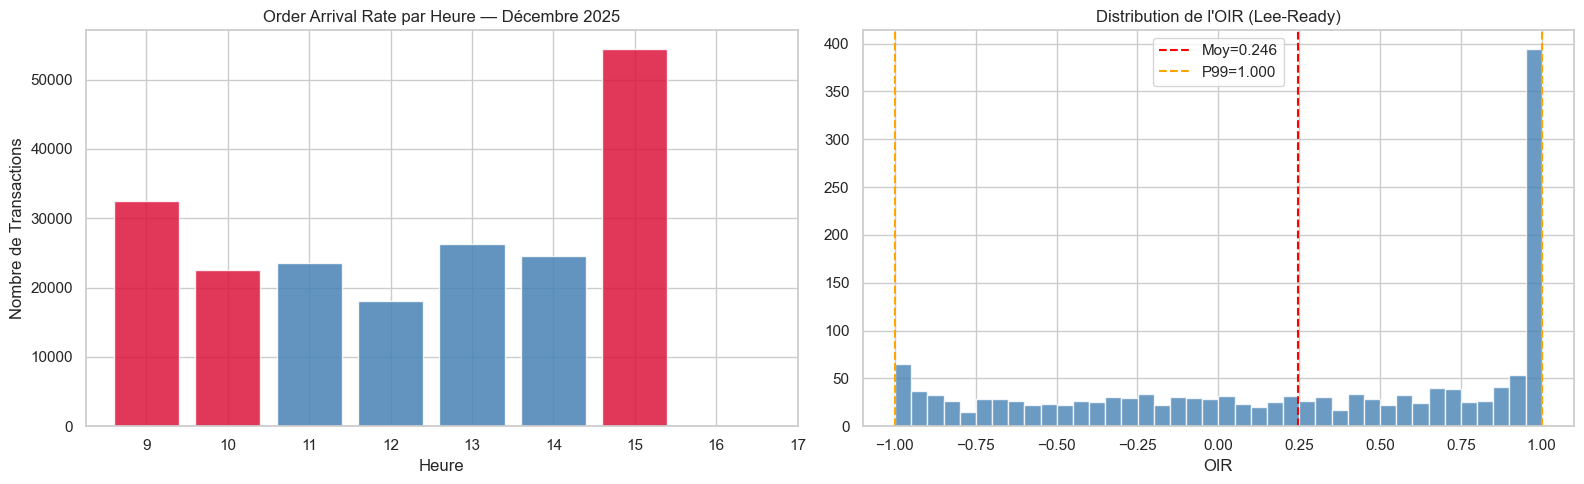

In [14]:
# OAR par heure (profil intraday du marché décembre)
df_intra_work = df_intra[df_intra['Sens'] == 'A'].copy()
df_intra_work['Heure_int'] = pd.to_datetime(df_intra_work['Heure_Transaction']).dt.hour
oar_horaire = df_intra_work.groupby('Heure_int').size().reset_index(name='Nb_Transactions')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# OAR par heure
axes[0].bar(oar_horaire['Heure_int'], oar_horaire['Nb_Transactions'],
            color=['crimson' if h in [9, 10, 15] else 'steelblue'
                   for h in oar_horaire['Heure_int']],
            alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Nombre de Transactions')
axes[0].set_title('Order Arrival Rate par Heure — Décembre 2025')
axes[0].set_xticks(range(9, 18))

# Distribution OIR
oir_clean = df_of['OIR'].dropna()
p99_oir = oir_clean.abs().quantile(0.99)
axes[1].hist(oir_clean, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(oir_clean.mean(), color='red', linestyle='--', label=f'Moy={oir_clean.mean():.3f}')
axes[1].axvline(p99_oir, color='orange', linestyle='--', label=f'P99={p99_oir:.3f}')
axes[1].axvline(-p99_oir, color='orange', linestyle='--')
axes[1].set_xlabel('OIR')
axes[1].set_title('Distribution de l\'OIR (Lee-Ready)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/08_orderflow_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

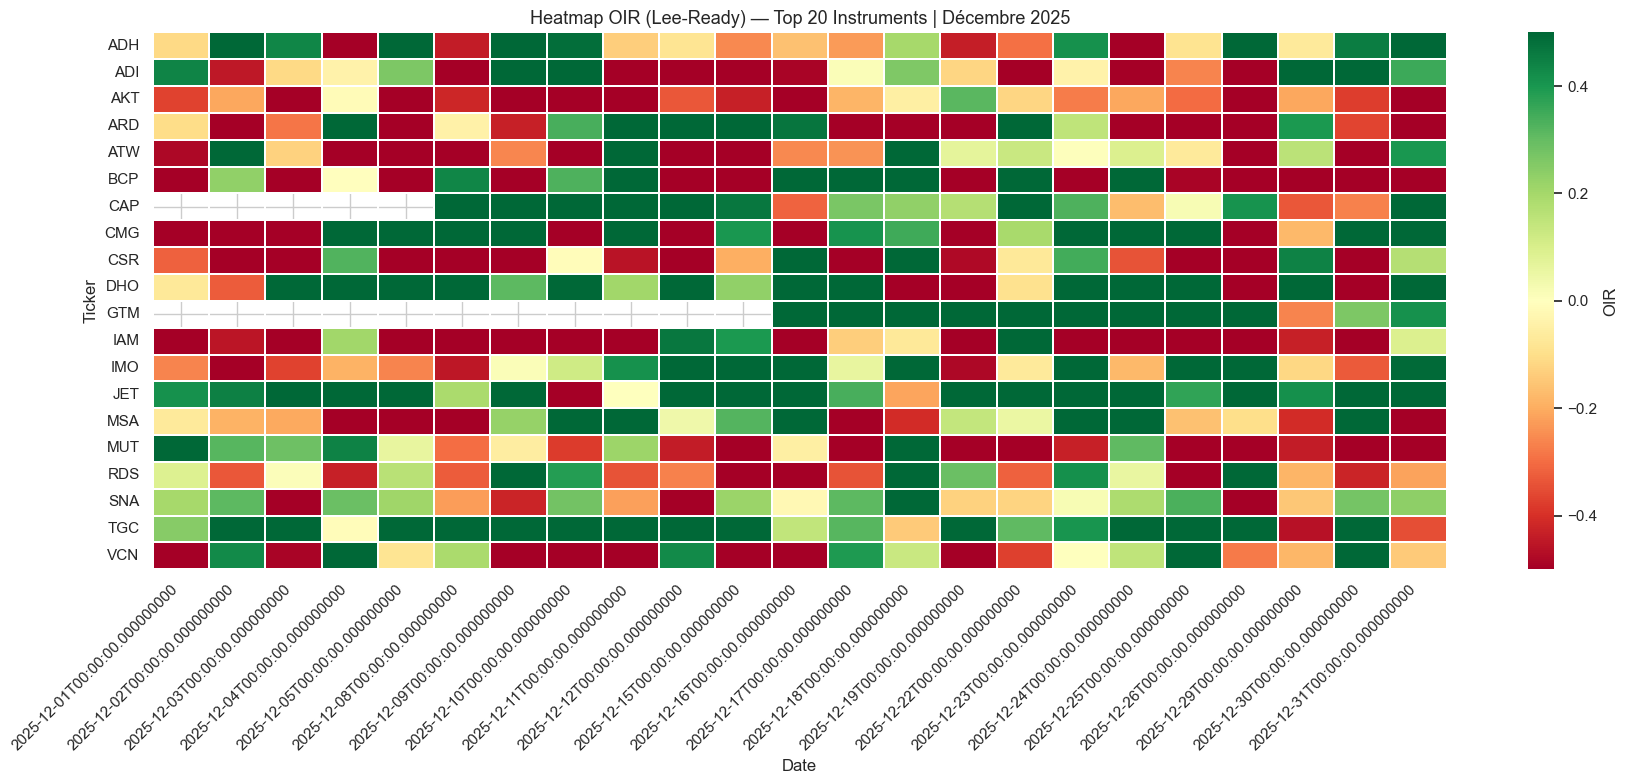

In [15]:
# Heatmap OIR par (Jour × Ticker) — Top 20 instruments
top20 = (df_of.groupby('Ticker')['Nb_Transactions']
         .sum().nlargest(20).index.tolist())
oir_pivot = (df_of[df_of['Ticker'].isin(top20)]
             .pivot_table(index='Ticker', columns='Jour', values='OIR'))

plt.figure(figsize=(18, 8))
sns.heatmap(oir_pivot, cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5,
            linewidths=0.3, cbar_kws={'label': 'OIR'})
plt.title('Heatmap OIR (Lee-Ready) — Top 20 Instruments | Décembre 2025', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Ticker')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/09_heatmap_OIR.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Scoring des Alertes Composite

In [16]:
print('Calcul des scores d\'alerte...')
df_alerts = compute_alert_scores(df_instr, df_market, df_of)
print(f'Alertes calculées : {len(df_alerts):,} (Ticker × Jour)')
print()
print('Distribution des sévérités :')
display(df_alerts['Severite'].value_counts())

Calcul des scores d'alerte...
Alertes calculées : 19,164 (Ticker × Jour)

Distribution des sévérités :


Severite
Normal      17939
Faible       1194
Modéré         31
Critique        0
Name: count, dtype: int64

In [17]:
# Top alertes critiques
print('=== TOP 30 ALERTES (Score Décroissant) ===')
top_al = get_top_alerts(df_alerts, n=30)
display(top_al[['Jour','Ticker','Libelle','Score_Alerte','Severite',
                 'Alert_Rendement','Alert_Volume','Alert_Volatilite',
                 'Rendement_pct','Volume_Relatif','Volatilite_20j']])

=== TOP 30 ALERTES (Score Décroissant) ===


,Jour,Ticker,Libelle,Score_Alerte,Severite,Alert_Rendement,Alert_Volume,Alert_Volatilite,Rendement_pct,Volume_Relatif,Volatilite_20j
0,2025-07-09,EQD,EQDOM,70.0000,Modéré,1.0000,1.0000,1.0000,9.3836,8.5191,5.8132
1,2025-07-10,IBC,IB MAROC.COM,70.0000,Modéré,1.0000,1.0000,1.0000,9.9859,3.1132,7.8888
2,2025-02-10,MOX,MAGHREB OXYGENE,70.0000,Modéré,1.0000,1.0000,1.0000,-8.9253,2.0234,5.8761
3,2025-06-13,STR,STROC INDUSTRIE,70.0000,Modéré,1.0000,1.0000,1.0000,9.9831,5.8963,5.9466
4,2025-06-19,STR,STROC INDUSTRIE,70.0000,Modéré,1.0000,1.0000,1.0000,-9.9769,5.7432,6.7743
5,2025-07-11,STR,STROC INDUSTRIE,70.0000,Modéré,1.0000,1.0000,1.0000,9.9929,1.6438,8.7717
6,2025-07-10,INV,INVOLYS,70.0000,Modéré,1.0000,1.0000,1.0000,9.9900,3.7860,8.7115
7,2025-08-04,INV,INVOLYS,70.0000,Modéré,1.0000,1.0000,1.0000,9.9686,4.2548,5.7770
8,2025-12-26,GTM,SGTM S.A,65.0000,Modéré,1.0000,1.0000,0.0000,-9.9922,5.3798,NaN
9,2025-06-30,INV,INVOLYS,60.0000,Modéré,1.0000,1.0000,0.5000,9.9974,4.1355,5.1606


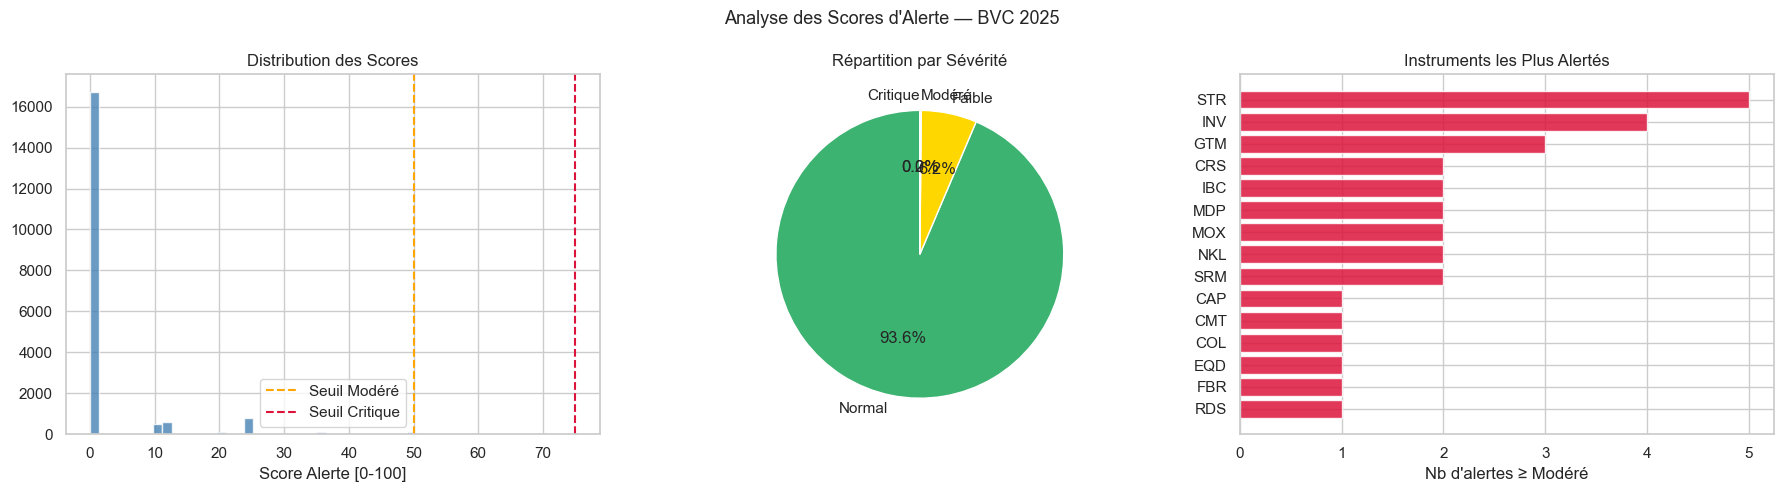

In [18]:
# Distribution des scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analyse des Scores d\'Alerte — BVC 2025', fontsize=13)

# Histogramme
axes[0].hist(df_alerts['Score_Alerte'].dropna(), bins=50,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(50, color='orange', linestyle='--', label='Seuil Modéré')
axes[0].axvline(75, color='crimson', linestyle='--', label='Seuil Critique')
axes[0].set_xlabel('Score Alerte [0-100]')
axes[0].set_title('Distribution des Scores')
axes[0].legend()

# Pie sévérités
sev_counts = df_alerts['Severite'].value_counts()
colors_sev = ['mediumseagreen', 'gold', 'darkorange', 'crimson']
axes[1].pie(sev_counts.values, labels=sev_counts.index,
            colors=colors_sev[:len(sev_counts)],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition par Sévérité')

# Top instruments par nb alertes critiques
critiques = df_alerts[df_alerts['Severite'].isin(['Modéré', 'Critique'])]
top_crit = critiques.groupby('Ticker').size().nlargest(15)
axes[2].barh(top_crit.index[::-1], top_crit.values[::-1], color='crimson', alpha=0.85)
axes[2].set_xlabel('Nb d\'alertes ≥ Modéré')
axes[2].set_title('Instruments les Plus Alertés')

plt.tight_layout()
plt.savefig('../reports/10_scores_alertes.png', dpi=150, bbox_inches='tight')
plt.show()

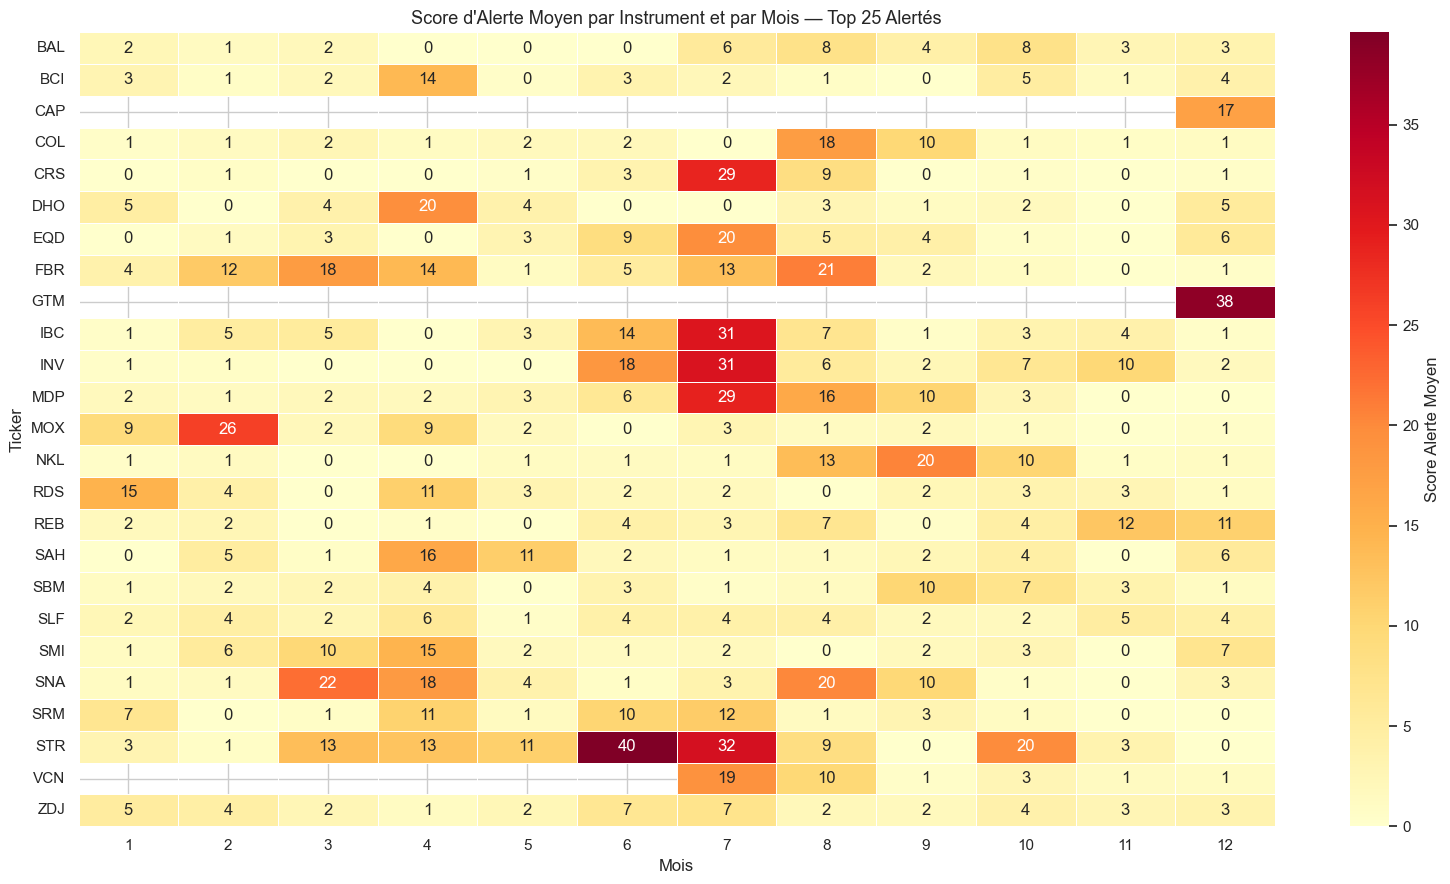

In [19]:
# Heatmap des alertes par instrument et par mois
df_alerts_m = df_alerts.copy()
df_alerts_m['Mois'] = pd.to_datetime(df_alerts_m['Jour']).dt.month_name()
df_alerts_m['Mois_num'] = pd.to_datetime(df_alerts_m['Jour']).dt.month

top_alert_tickers = (df_alerts_m.groupby('Ticker')['Score_Alerte']
                     .mean().nlargest(25).index.tolist())
heat_data = (df_alerts_m[df_alerts_m['Ticker'].isin(top_alert_tickers)]
             .groupby(['Ticker', 'Mois_num'])['Score_Alerte']
             .mean().unstack())

plt.figure(figsize=(16, 9))
sns.heatmap(heat_data, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Score Alerte Moyen'})
plt.title('Score d\'Alerte Moyen par Instrument et par Mois — Top 25 Alertés', fontsize=13)
plt.xlabel('Mois')
plt.ylabel('Ticker')
plt.tight_layout()
plt.savefig('../reports/11_heatmap_alertes_mensuelles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Sauvegarde des résultats

In [20]:
import os
DATA_DIR = '../data'

df_market.to_parquet(f'{DATA_DIR}/market_indicators.parquet', index=False)
df_instr.to_parquet(f'{DATA_DIR}/instrument_indicators.parquet', index=False)
df_of.to_parquet(f'{DATA_DIR}/orderflow_indicators.parquet', index=False)
df_alerts.to_parquet(f'{DATA_DIR}/alert_scores.parquet', index=False)

# Sauvegarde des seuils statistiques en CSV (pour le dashboard)
seuils_all = pd.concat([seuils_market, seuils_instr, seuils_of], ignore_index=True)
seuils_all.to_csv(f'{DATA_DIR}/seuils_statistiques.csv', index=False)

print('✓ Fichiers sauvegardés :')
for f in ['market_indicators.parquet','instrument_indicators.parquet',
          'orderflow_indicators.parquet','alert_scores.parquet','seuils_statistiques.csv']:
    size = os.path.getsize(f'{DATA_DIR}/{f}')
    print(f'  {f} ({size/1024:.0f} KB)')

✓ Fichiers sauvegardés :
  market_indicators.parquet (52 KB)
  instrument_indicators.parquet (3124 KB)
  orderflow_indicators.parquet (195 KB)
  alert_scores.parquet (1259 KB)
  seuils_statistiques.csv (5 KB)


In [21]:
print("""
╔═══════════════════════════════════════════════════════════════════╗
║        RÉSUMÉ — PHASE 2 INDICATEURS COMPLÉTÉE                    ║
╠═══════════════════════════════════════════════════════════════════╣
║ MARCHÉ GLOBAL (247 séances)                                       ║
║   ✓ MASI rendement, volatilité rolling 5j/20j                    ║
║   ✓ Volume relatif marché vs moyenne 20j                         ║
║   ✓ Breadth du marché (% instruments en hausse)                  ║
║   ✓ HHI de concentration des volumes                             ║
╠═══════════════════════════════════════════════════════════════════╣
║ PAR INSTRUMENT (~19,000 lignes × 77 titres)                       ║
║   ✓ Rendement journalier, écart cours-ref                        ║
║   ✓ Volatilité rolling 5j / 10j / 20j                            ║
║   ✓ Volume relatif (vs moy. 20j)                                 ║
║   ✓ Turnover ratio, Spread bid-ask, Range journalier             ║
║   ✓ RSI 14j, Momentum 5j/20j                                     ║
║   ✓ Score de liquidité composite [0-1]                           ║
║   ✓ Z-scores individuels (rendement, volume, volatilité)         ║
╠═══════════════════════════════════════════════════════════════════╣
║ FLUX D'ORDRES — INTRADAY (201,733 transactions uniques)           ║
║   ✓ Lee-Ready Tick Rule → classification buy/sell                ║
║   ✓ OIR (Order Imbalance Ratio) par (Jour × Ticker)             ║
║   ✓ OAR (Order Arrival Rate)                                     ║
║   ✓ VWAP et VWAP Déviation vs clôture                           ║
║   ✓ Volatilité intraday normalisée                               ║
║   ✓ Concentration volume Open/Close                              ║
╠═══════════════════════════════════════════════════════════════════╣
║ SCORING DES ALERTES                                               ║
║   ✓ Score composite pondéré [0-100]                              ║
║   ✓ Niveaux : Normal / Faible / Modéré / Critique               ║
║   ✓ Seuils P95/P99 et Z-score > 2.5 calculés                    ║
╠═══════════════════════════════════════════════════════════════════╣
║ PROCHAINE ÉTAPE → Phase 4 : Dashboard Streamlit + Upload Excel   ║
╚═══════════════════════════════════════════════════════════════════╝
""")


╔═══════════════════════════════════════════════════════════════════╗
║        RÉSUMÉ — PHASE 2 INDICATEURS COMPLÉTÉE                    ║
╠═══════════════════════════════════════════════════════════════════╣
║ MARCHÉ GLOBAL (247 séances)                                       ║
║   ✓ MASI rendement, volatilité rolling 5j/20j                    ║
║   ✓ Volume relatif marché vs moyenne 20j                         ║
║   ✓ Breadth du marché (% instruments en hausse)                  ║
║   ✓ HHI de concentration des volumes                             ║
╠═══════════════════════════════════════════════════════════════════╣
║ PAR INSTRUMENT (~19,000 lignes × 77 titres)                       ║
║   ✓ Rendement journalier, écart cours-ref                        ║
║   ✓ Volatilité rolling 5j / 10j / 20j                            ║
║   ✓ Volume relatif (vs moy. 20j)                                 ║
║   ✓ Turnover ratio, Spread bid-ask, Range journalier             ║
║   ✓ RSI 14j, Momentum 5j/2